In [11]:
install.packages("sqldf")
install.packages("dplyr")

library(sqldf)
library(dplyr)
library(DBI)
library(RSQLite)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
customers <- read.csv("customers.csv")
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
hubs <- read.csv("hubs.csv")
complaints <- read.csv("complaints.csv")
incidents <- read.csv("incidents.csv")
app_events <- read.csv("app_events.csv")

In [6]:
str(customers)
str(orders)
str(deliveries)
str(complaints)

'data.frame':	650 obs. of  9 variables:
 $ customer_id         : chr  "C0001" "C0002" "C0003" "C0004" ...
 $ age                 : int  26 61 66 75 26 41 54 70 34 23 ...
 $ home_zone           : chr  "North" "AIRPORT" "East" "CENTRAL" ...
 $ customer_type       : chr  "SME" "Consumer" "Consumer" "Consumer" ...
 $ signup_date         : chr  "2024-11-27 04:25:00" "2025-10-28 01:04:00" "2025-07-02 03:23:00" "2025-08-19 01:58:00" ...
 $ loyalty_score       : num  44.9 55.4 75.9 32.5 55.9 39.9 36.1 84.6 62.6 87.2 ...
 $ app_engagement_score: num  69.2 66.6 33.8 33 100 43.3 39 65.2 40.8 48.6 ...
 $ preferred_channel   : chr  "App" "App" "" "App" ...
 $ account_status      : chr  "Active" "Active" "Active" "Active" ...
'data.frame':	1250 obs. of  11 variables:
 $ order_id             : chr  "O00001" "O00002" "O00003" "O00004" ...
 $ customer_id          : chr  "C0292" "C0459" "C0161" "C0520" ...
 $ service_type         : chr  "Passenger" "Passenger" "Passenger" "Parcel" ...
 $ order_created_a

In [7]:
head(deliveries)
head(orders)
head(hubs)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


,hub_id,hub_name,zone,hub_type,capacity_score
,<chr>,<chr>,<chr>,<chr>,<int>
1,H01,North Exchange,North,Dispatch,82
2,H02,South Link,South,Dispatch,78
3,H03,East Dock,East,Warehouse,74
4,H04,West Gate,West,Dispatch,69
5,H05,Central Core,Central,Control,88
6,H06,Airport Hub,Airport,Dispatch,71


In [8]:
names(deliveries)
names(orders)
names(hubs)
names(complaints)
names(vehicles)
names(incidents)

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "hub_id"         "hub_name"       "zone"           "hub_type"      
[5] "capacity_score"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "vehicle_id"         "vehicle_type"       "assigned_zone"     
[4] "commission_date"    "battery_health_pct" "odometer_km"       
[7] "maintenance_status" "telematics_version"

[1] "incident_id"       "delivery_id"       "incident_type"    
[4] "reported_at"       "severity"          "resolution_status"
[7] "resolved_hours"

In [12]:
failure_by_zone <- sqldf("
SELECT
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(d.delivery_id),
        2
    ) AS failure_rate_percentage
FROM deliveries d
JOIN hubs h
    ON d.hub_id = h.hub_id
GROUP BY h.zone
ORDER BY failure_rate_percentage DESC
")

failure_by_zone

zone,total_deliveries,failed_deliveries,failure_rate_percentage
<chr>,<int>,<int>,<dbl>
Central,243,49,20.16
Airport,104,15,14.42
West,127,16,12.60
North,136,17,12.50
Riverside,115,14,12.17
South,106,10,9.43
East,119,11,9.24


In [13]:
complaints_by_service <- sqldf("
SELECT
    o.service_type,
    COUNT(c.complaint_id) AS complaint_count,
    ROUND(AVG(c.resolution_days), 2) AS average_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS average_compensation
FROM complaints c
JOIN orders o
    ON c.order_id = o.order_id
GROUP BY o.service_type
ORDER BY complaint_count DESC
")

complaints_by_service

service_type,complaint_count,average_resolution_days,average_compensation
<chr>,<int>,<dbl>,<dbl>
Passenger,84,7.74,20.72
Retail,83,7.89,19.05
Parcel,77,8.34,20.61
Business,39,7.95,20.79
Medical,37,7.57,20.56


In [14]:
vehicle_failure_analysis <- sqldf("
SELECT
    v.maintenance_status,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(AVG(v.battery_health_pct), 2) AS average_battery_health,
    ROUND(
        100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(d.delivery_id),
        2
    ) AS failure_rate_percentage
FROM deliveries d
JOIN vehicles v
    ON d.vehicle_id = v.vehicle_id
GROUP BY v.maintenance_status
ORDER BY failure_rate_percentage DESC
")

vehicle_failure_analysis

maintenance_status,total_deliveries,failed_deliveries,average_battery_health,failure_rate_percentage
<chr>,<int>,<int>,<dbl>,<dbl>
InRepair,254,77,76.73,30.31
Active,542,45,76.56,8.30
Scheduled,154,10,78.74,6.49


In [15]:
install.packages("ggplot2")
install.packages("dplyr")

library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



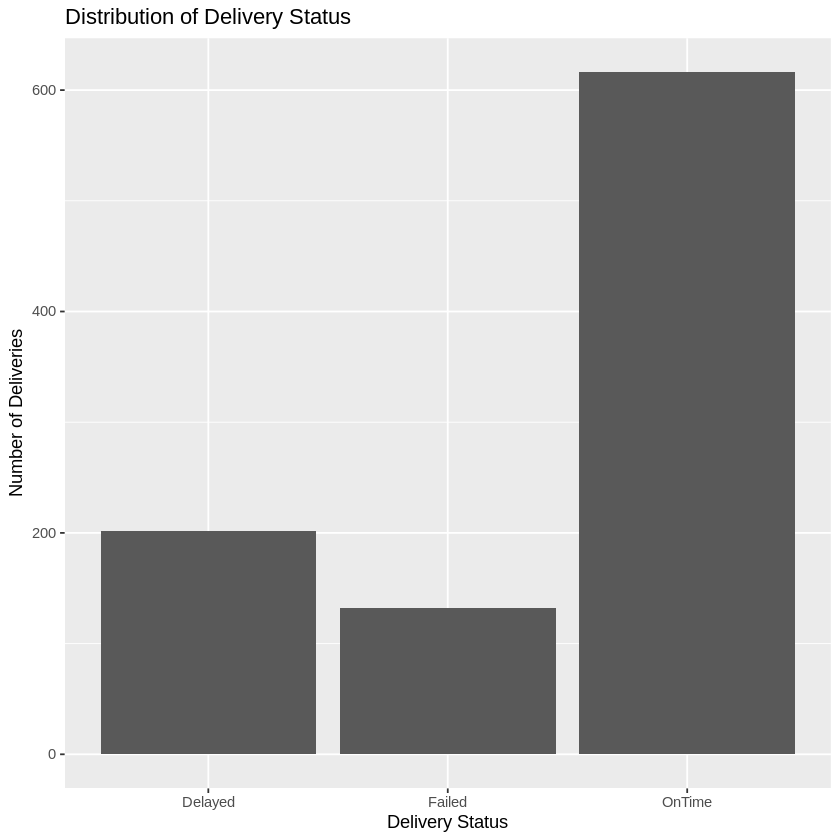

In [16]:
ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar() +
  labs(
    title = "Distribution of Delivery Status",
    x = "Delivery Status",
    y = "Number of Deliveries"
  )

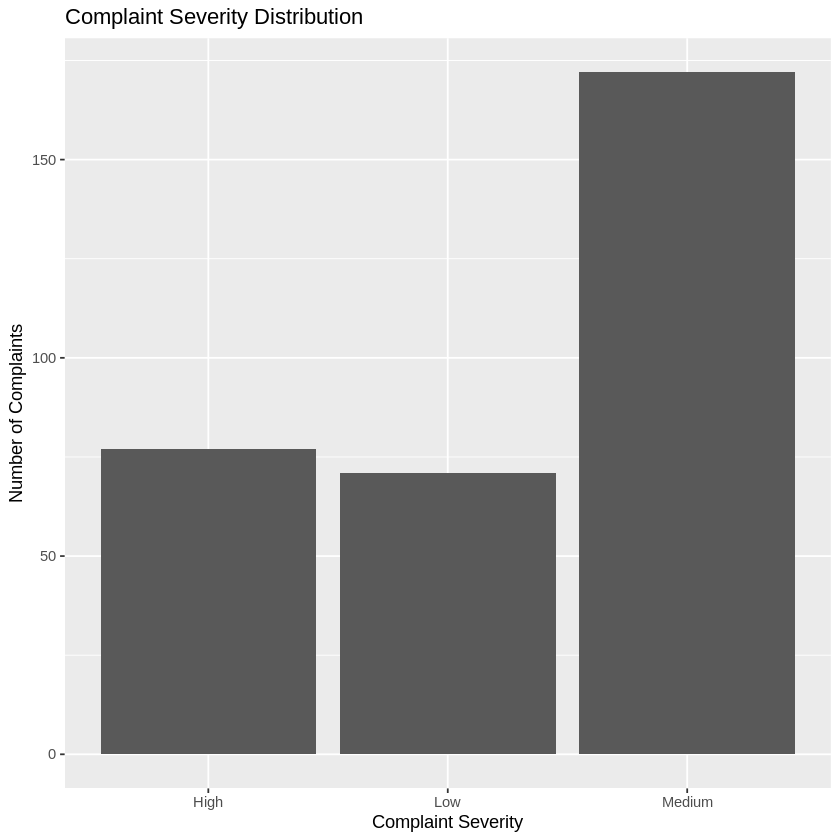

In [17]:
ggplot(complaints, aes(x = severity)) +
  geom_bar() +
  labs(
    title = "Complaint Severity Distribution",
    x = "Complaint Severity",
    y = "Number of Complaints"
  )

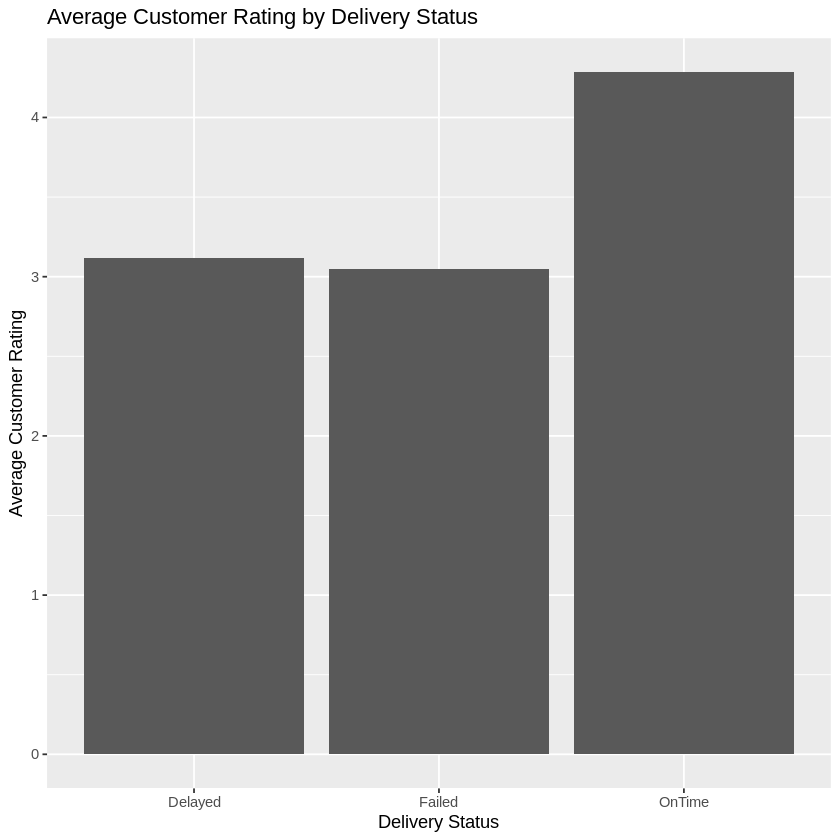

In [18]:
rating_by_status <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    average_rating = mean(customer_rating_post_delivery, na.rm = TRUE)
  )

ggplot(rating_by_status, aes(x = delivery_status, y = average_rating)) +
  geom_col() +
  labs(
    title = "Average Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Average Customer Rating"
  )

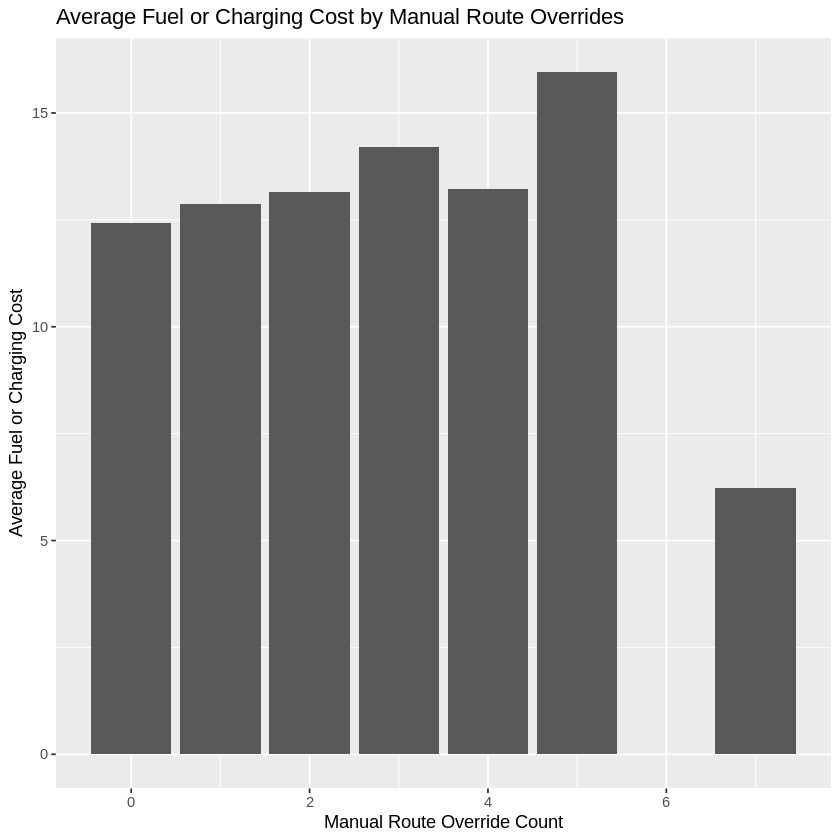

In [19]:
override_cost <- deliveries %>%
  group_by(manual_route_override_count) %>%
  summarise(
    average_cost = mean(fuel_or_charge_cost, na.rm = TRUE)
  )

ggplot(override_cost, aes(x = manual_route_override_count, y = average_cost)) +
  geom_col() +
  labs(
    title = "Average Fuel or Charging Cost by Manual Route Overrides",
    x = "Manual Route Override Count",
    y = "Average Fuel or Charging Cost"
  )

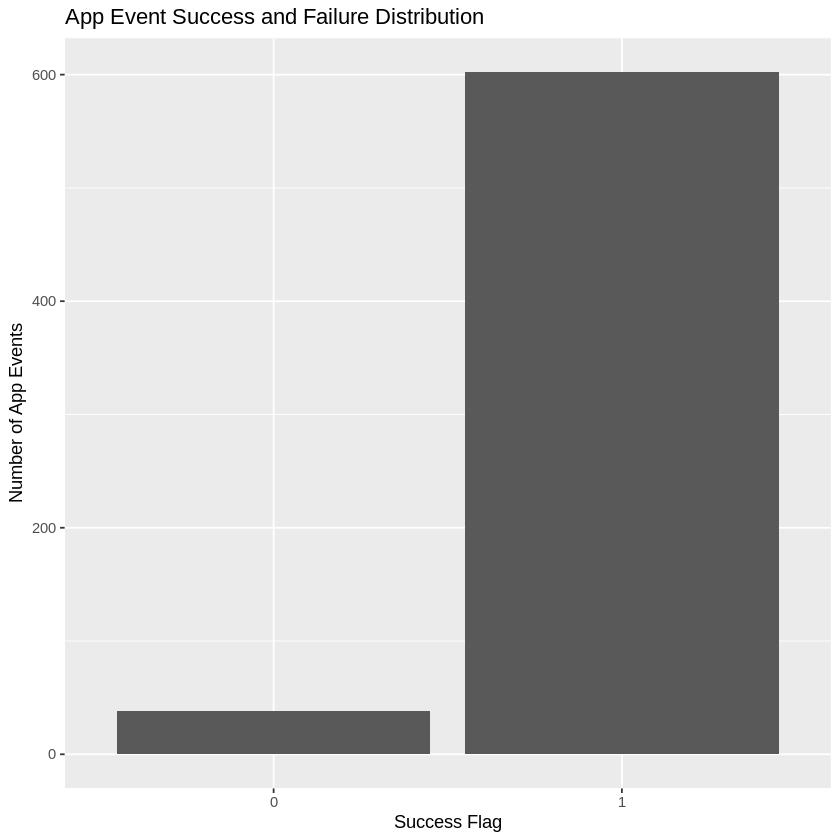

In [20]:
ggplot(app_events, aes(x = as.factor(success_flag))) +
  geom_bar() +
  labs(
    title = "App Event Success and Failure Distribution",
    x = "Success Flag",
    y = "Number of App Events"
  )

In [21]:
summary(deliveries$route_distance_km)
summary(deliveries$fuel_or_charge_cost)
summary(deliveries$customer_rating_post_delivery)
summary(vehicles$battery_health_pct)
summary(app_events$api_latency_ms)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.500   9.925  12.645  12.841  15.697  29.430 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  42.00   68.20   78.05   76.79   85.78  100.00       4 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   60.0   278.8   432.5   465.7   609.0  1701.0 